<a href="https://colab.research.google.com/github/utpal-maersk/ML-Projects/blob/main/PAN-Card-Tampering-Detector/notepad/pancard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PAN Card Tampering Detection

The purpose of this project is to detect PAN card tempering.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
from skimage.metrics import structural_similarity
import imutils
import cv2
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import requests

In [3]:
!mkdir pan_card_tampering
!mkdir pan_card_tampering/images

In [4]:
original=Image.open(requests.get('https://www.thestatesman.com/wp-content/uploads/2019/07/pan-card.jpg',stream=True).raw)
tampered=Image.open(requests.get('https://assets1.cleartax-cdn.com/s/img/20170526124335/Pan4.png',stream=True).raw)

In [5]:
print(original.size)
print(tampered.size)

(1200, 800)
(282, 179)


In [7]:
original=original.resize((260,160))
tampered=tampered.resize((260,160))
print(original.size)
print(tampered.size)
original.save('pan_card_tampering/images/original.png')
tampered.save('pan_card_tampering/images/tampered.png')


(260, 160)
(260, 160)


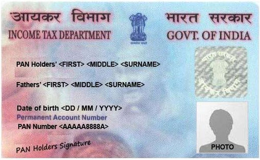

In [8]:
original

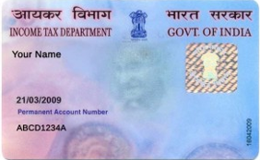

In [9]:
tampered

In [22]:
original=cv2.imread('pan_card_tampering/images/original.png')
tampered=cv2.imread('pan_card_tampering/images/tampered.png')
original_test=cv2.imread('pan_card_tampering/images/original.png')


In [23]:
original_gray=cv2.cvtColor(original,cv2.COLOR_BGR2GRAY)
tampered_gray=cv2.cvtColor(tampered,cv2.COLOR_BGR2GRAY)
original_test_gray=cv2.cvtColor(original_test,cv2.COLOR_BGR2GRAY)

In [24]:
(score,diff)=structural_similarity(original_gray,tampered_gray,full=True)
print("Image Similarity",score)
diff=(diff*255).astype("uint8")
print("Image Difference")
print(diff)

(score,diff)=structural_similarity(original_gray,original_test_gray,full=True)
print("Image Similarity",score)
diff=(diff*255).astype("uint8")
print("Image Difference")
print(diff)

Image Similarity 0.31695785475472327
Image Difference
[[219 205 193 ...  90  87  97]
 [216 214 206 ... 121 118 111]
 [218 218 219 ... 150 147 138]
 ...
 [176 198 200 ... 185 184 191]
 [166 192 182 ... 163 169 179]
 [143 181 175 ... 147 152 148]]
Image Similarity 1.0
Image Difference
[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


In [16]:
#calculating the threshold and conture

thresh=cv2.threshold(diff,0,255,cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
cnt=cv2.findContours(thresh.copy(),cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
cnt=imutils.grab_contours(cnt)

In [18]:
for c in cnt:
  (x,y,w,h)=cv2.boundingRect(c)
  cv2.rectangle(original,(x,y),(x+w,y+h),(0,0,255),2)
  cv2.rectangle(tampered,(x,y),(x+w,y+h),(0,0,255),2)

Original Format Image


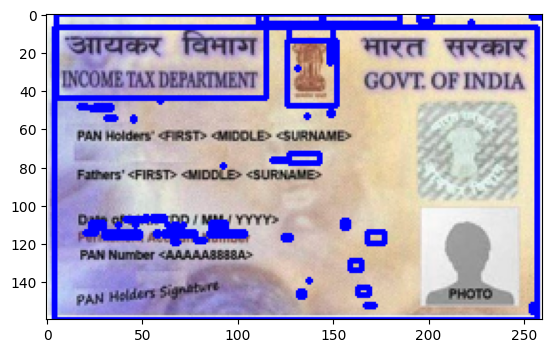

Tampered Format Image


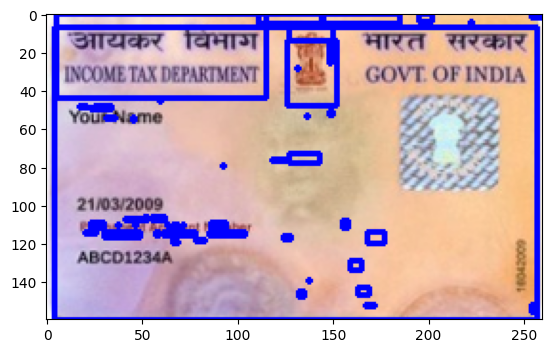

In [19]:
print("Original Format Image")
plt.imshow(original)
plt.show()
print("Tampered Format Image")
plt.imshow(tampered)
plt.show()


Difference Image


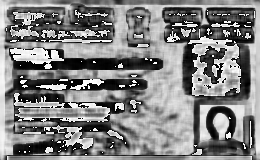

In [20]:
print('Difference Image')
Image.fromarray(diff)

Threshold Images


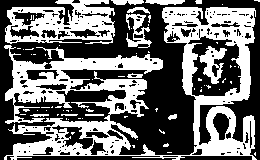

In [21]:
print("Threshold Images")
Image.fromarray(thresh)

Summary:
Structural Similarity different is only 31%